# Bibliografía
Link: https://meteo.navarra.es/definiciones/elementosfactores.cfm#:~:text=Los%20factores%20del%20clima%20son,los%20distintos%20tipos%20de%20climas.

# SETUP

In [1]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import gdown
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split  # Para dividir los datos
from sklearn.pipeline import Pipeline    # Para construir pipelines
from sklearn.linear_model import LogisticRegression   # Modelo de regresión logística
from sklearn.ensemble import RandomForestClassifier   # Modelo Random Forest
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   RainToday     142193 non-null  int64  
 1   Cloud3pm      142193 non-null  float64
 2   Temp3pm       142193 non-null  float64
 3   Humidity3pm   142193 non-null  float64
 4   Pressure3pm   142193 non-null  float64
 5   RainTomorrow  142193 non-null  int64  
 6   WindDir_ENE   142193 non-null  int64  
 7   WindDir_ESE   142193 non-null  int64  
 8   WindDir_N     142193 non-null  int64  
 9   WindDir_NE    142193 non-null  int64  
 10  WindDir_NNE   142193 non-null  int64  
 11  WindDir_NNW   142193 non-null  int64  
 12  WindDir_NW    142193 non-null  int64  
 13  WindDir_S     142193 non-null  int64  
 14  WindDir_SE    142193 non-null  int64  
 15  WindDir_SSE   142193 non-null  int64  
 16  WindDir_SSW   142193 non-null  int64  
 17  WindDir_SW    142193 non-null  int64  
 18  Wind

In [2]:
df = pd.read_csv('datos_preprocesados.csv')

In [3]:
df.columns

Index(['RainToday', 'Cloud3pm', 'Temp3pm', 'Humidity3pm', 'Pressure3pm',
       'RainTomorrow', 'WindDir_ENE', 'WindDir_ESE', 'WindDir_N', 'WindDir_NE',
       'WindDir_NNE', 'WindDir_NNW', 'WindDir_NW', 'WindDir_S', 'WindDir_SE',
       'WindDir_SSE', 'WindDir_SSW', 'WindDir_SW', 'WindDir_W', 'WindDir_WNW',
       'WindDir_WSW'],
      dtype='object')

# CRISP-DM

## 4. MODELADO

### Modelo 1 - Regresión Logística

In [4]:
# 1. Preparar datos
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# 2. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Definir pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),            # Ajusta solo con X_train
    ('clf',   LogisticRegression(
                  random_state=42,
                  max_iter=1000
             ))
])

# 4. Entrenar
pipe_lr.fit(X_train, y_train)

# 5. Predecir y evaluar
y_pred_lr  = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print("=== Regresión Logística ===")
print("Accuracy:",      accuracy_score(y_test, y_pred_lr))
print("ROC AUC:",       roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr, digits=4))

=== Regresión Logística ===
Accuracy: 0.8559941863190961
ROC AUC: 0.9009466203695227
              precision    recall  f1-score   support

           0     0.8884    0.9314    0.9094     33095
           1     0.7149    0.5949    0.6494      9563

    accuracy                         0.8560     42658
   macro avg     0.8016    0.7632    0.7794     42658
weighted avg     0.8495    0.8560    0.8511     42658



### Modelo 2 - Random Forest

In [5]:
# 1. Preparar datos (suponemos el mismo df)
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# 2. División train/test (idéntica para poder comparar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Definir y entrenar
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train, y_train)

# 4. Predecir y evaluar
y_pred_rf  = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:",      accuracy_score(y_test, y_pred_rf))
print("ROC AUC:",       roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

=== Random Forest ===
Accuracy: 0.8723803272539734
ROC AUC: 0.9176218326610924
              precision    recall  f1-score   support

           0     0.9000    0.9399    0.9195     33095
           1     0.7544    0.6387    0.6917      9563

    accuracy                         0.8724     42658
   macro avg     0.8272    0.7893    0.8056     42658
weighted avg     0.8674    0.8724    0.8685     42658



### Modelo 3 - XGB Boost

In [6]:
# 1. Preparar datos
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# 2. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Definir pipeline
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),  # Opcional con árboles, pero útil si usas interacciones mixtas
    ('clf', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

# 4. Entrenar
pipe_xgb.fit(X_train, y_train)

# 5. Predecir y evaluar
y_pred_xgb  = pipe_xgb.predict(X_test)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print("=== XGBoostClassifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:",  roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:49:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


=== XGBoostClassifier ===
Accuracy: 0.8776782784003001
ROC AUC: 0.9252391164851275
              precision    recall  f1-score   support

           0     0.9036    0.9429    0.9228     33095
           1     0.7675    0.6519    0.7050      9563

    accuracy                         0.8777     42658
   macro avg     0.8355    0.7974    0.8139     42658
weighted avg     0.8731    0.8777    0.8740     42658



In [7]:
# Métricas globales
acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_proba_lr)

acc_rf  = accuracy_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Comparativa
print("=== Comparativa ===")
print(f"{'Modelo':<25}{'Accuracy':<12}{'ROC AUC'}")
print(f"{'Regresión Logística':<25}{acc_lr:.4f}      {auc_lr:.4f}")
print(f"{'Random Forest':<25}{acc_rf:.4f}      {auc_rf:.4f}")
print(f"{'XGBoostClassifier':<25}{acc_xgb:.4f}      {auc_xgb:.4f}")


=== Comparativa ===
Modelo                   Accuracy    ROC AUC
Regresión Logística      0.8560      0.9009
Random Forest            0.8724      0.9176
XGBoostClassifier        0.8777      0.9252


XGBoost fue el modelo con mejor desempeño, alcanzando un *accuracy* de **87.77%** y un *ROC AUC* de **0.9252**, seguido por Random Forest con valores muy similares. La Regresión Logística mostró un rendimiento algo inferior, aunque aún competitivo. En general, los modelos basados en árboles resultan más efectivos para este problema de predicción climática.


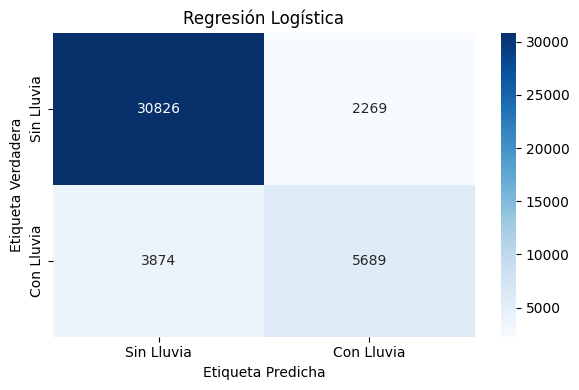


Regresión Logística (matriz de confusión):
               Sin Lluvia     Con Lluvia
Sin Lluvia     30826          2269
Con Lluvia     3874           5689



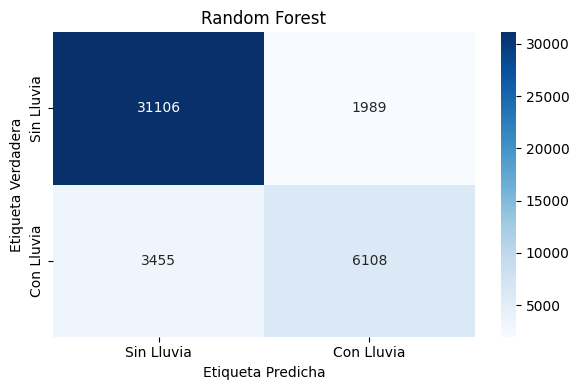


Random Forest (matriz de confusión):
               Sin Lluvia     Con Lluvia
Sin Lluvia     31106          1989
Con Lluvia     3455           6108



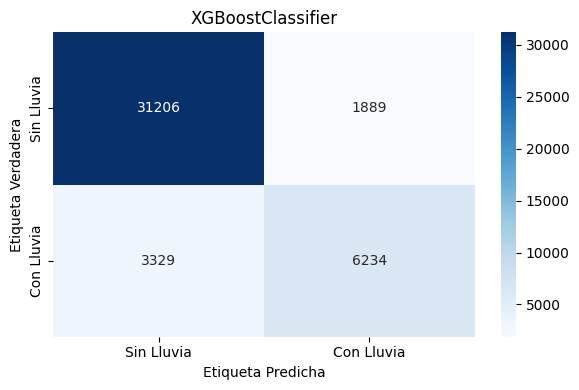


XGBoostClassifier (matriz de confusión):
               Sin Lluvia     Con Lluvia
Sin Lluvia     31206          1889
Con Lluvia     3329           6234



In [11]:
# Función para graficar la matriz de confusión
def mostrar_matriz_confusion(y_verdadero, y_predicho, titulo="Matriz de Confusión"):
    cm = confusion_matrix(y_verdadero, y_predicho)
    etiquetas = ['Sin Lluvia', 'Con Lluvia']

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas)
    plt.title(titulo)
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()
    plt.show()

    # Imprimir matriz en formato texto
    print(f"\n{titulo} (matriz de confusión):")
    print(f"{'':<15}{etiquetas[0]:<15}{etiquetas[1]}")
    print(f"{etiquetas[0]:<15}{cm[0][0]:<15}{cm[0][1]}")
    print(f"{etiquetas[1]:<15}{cm[1][0]:<15}{cm[1][1]}\n")

# Matriz para Regresión Logística
mostrar_matriz_confusion(y_test, y_pred_lr, "Regresión Logística")

# Matriz para Random Forest
mostrar_matriz_confusion(y_test, y_pred_rf, "Random Forest")

# Matriz para XGBoost
mostrar_matriz_confusion(y_test, y_pred_xgb, "XGBoostClassifier")

### Conclusión basada en las matrices de confusión

Dado que en este caso no es crítico priorizar los falsos positivos ni negativos, se ha optado por tomar el *accuracy* como principal criterio de evaluación. Bajo esta métrica, el modelo **XGBoost** se posiciona como el más adecuado, al lograr el mayor número de aciertos totales en la clasificación de días con y sin lluvia.
